In [257]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [258]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train Shape: ", train.shape)
print("Test Shape: ", test.shape)

print(train.info())
print(test.info())

Train Shape:  (1460, 81)
Test Shape:  (1459, 80)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  Ove

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64
Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64


<Axes: >

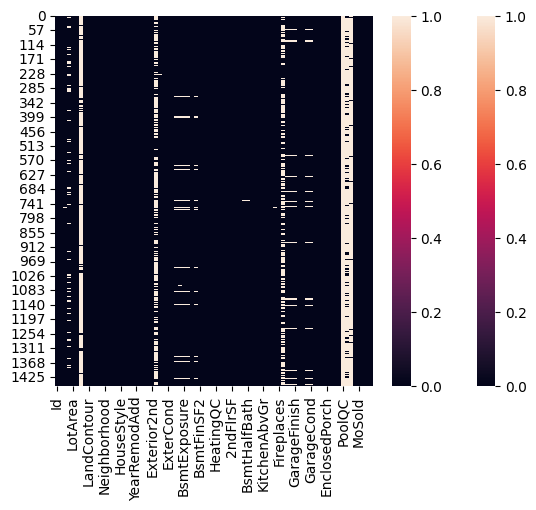

In [259]:
print(train.isnull().sum())
sns.heatmap(train.isnull())

print(test.isnull().sum())
sns.heatmap(test.isnull())

In [260]:
cat_col_train = [
    'FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFinType2', 'FireplaceQu', 'GarageQual', 'GarageCond'
]

ncat_col_train = [
    'LotFrontage', 'GarageYrBlt', 'MasVnrArea'
]

for i in cat_col_train:
    train[i] = train[i].fillna(train[i].mode()[0])

for j in ncat_col_train:
    train[j] = train[j].fillna(train[j].mean())

In [261]:
cat_col_test = [
    'FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFinType2', 'FireplaceQu', 'GarageQual', 'GarageCond',
    'MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd',
    'KitchenQual', 'Functional', 'SaleType'
]

ncat_col_test = [
    'LotFrontage', 'GarageYrBlt', 'MasVnrArea',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea'
]

for i in cat_col_test:
    test[i] = test[i].fillna(test[i].mode()[0])

for j in ncat_col_test:
    test[j] = test[j].fillna(test[j].mean())

Train Shape:  (1460, 76)
Test Shape:  (1459, 75)


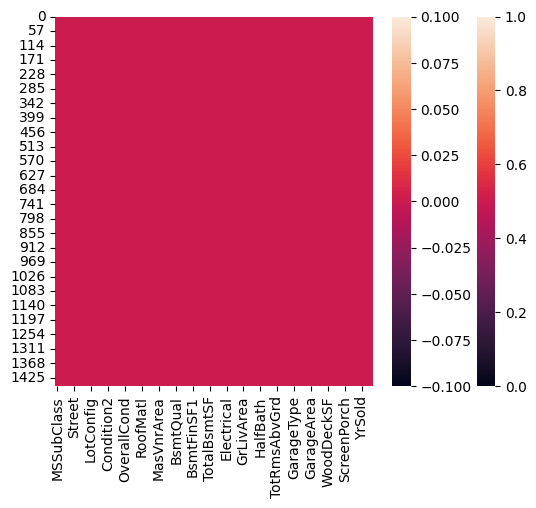

In [262]:
to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']

for k in to_drop:
    train.drop([k], axis=1, inplace=True)
    test.drop([k], axis=1, inplace=True)

sns.heatmap(train.isnull())
sns.heatmap(test.isnull())

print("Train Shape: ", train.shape)
print("Test Shape: ", test.shape)

In [263]:
final_df = pd.concat([train, test], axis=0)

print(final_df.shape)

(2919, 76)


In [264]:
all_cat_col = [
    'MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
    'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1',
    'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle',
    'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
    'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
    'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
    'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType',
    'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
    'SaleType', 'SaleCondition'
]

In [265]:
def cat_onehot_encoding(multicol):
    df_final = final_df
    i = 0

    for fields in multicol:
        print(fields)

        df1 = pd.get_dummies(
            final_df[fields],
            drop_first=True
        )

        final_df.drop([fields], axis=1, inplace=True)

        if i == 0:
            df_final = df1.copy()
        else:
            df_final = pd.concat([df_final, df1], axis=1)

        i = i + 1

    df_final = pd.concat([final_df, df_final], axis=1)

    return df_final


final_df = cat_onehot_encoding(all_cat_col)

print(final_df.shape)

MSZoning
Street
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Heating
HeatingQC
CentralAir
Electrical
KitchenQual
Functional
FireplaceQu
GarageType
GarageFinish
GarageQual
GarageCond
PavedDrive
SaleType
SaleCondition
(2919, 236)


In [266]:
final_df = final_df.loc[:, ~final_df.columns.duplicated()]

print(final_df.shape)

(2919, 176)


In [267]:
df_train = final_df.iloc[:1460, :]
df_test = final_df.iloc[1460:, :]

df_test.drop(['SalePrice'], axis=1, inplace=True)

print("Train Shape: ", df_train.shape)
print("Test Shape: ", df_test.shape)

Train Shape:  (1460, 176)
Test Shape:  (1459, 175)


C:\Users\MINH HAI\AppData\Local\Temp\ipykernel_25496\2206448745.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test.drop(['SalePrice'], axis=1, inplace=True)


In [268]:
x_train = df_train.drop(['SalePrice'], axis=1)
y_train = df_train['SalePrice']

print("X train:", x_train.shape)
print("Y train:", y_train.shape)

X train: (1460, 175)
Y train: (1460,)


In [269]:
from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.25,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

X_train: (1095, 175)
X_val: (365, 175)


In [270]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import time

In [271]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, Y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [272]:
pred_rf_val = rf_model.predict(X_val)

print(pred_rf_val.shape)
print(pred_rf_val[:10])

(365,)
[143822.25 313889.38 118967.5  158636.5  306733.23  83853.   210248.
 151862.85  84757.   131464.37]


In [273]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(Y_val, pred_rf_val)

rmse = np.sqrt(
    mean_squared_error(Y_val, pred_rf_val)
)

r2 = r2_score(Y_val, pred_rf_val)

print("========== RANDOM FOREST ==========")
print("MAE  :", mae)
print("RMSE :", rmse)
print("R2   :", r2)

========== RANDOM FOREST ==========
MAE  : 17218.288566210045
RMSE : 27602.68895884317
R2   : 0.8912384261613391


In [274]:
param_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

print(param_rf)

{'n_estimators': [100, 200, 300, 500], 'max_depth': [None, 10, 15, 20, 30], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 'log2']}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_search = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

random_cv_rf = RandomizedSearchCV(
    estimator=rf_search,
    param_distributions=param_rf,
    cv=5,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_cv_rf.fit(x_train, y_train)

print("Randomized Search completed!")

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [ ]:
print("========== BEST PARAMETERS ==========")

print(random_cv_rf.best_params_)

print("\n========== BEST MAE ==========")

print(-random_cv_rf.best_score_)

========== BEST PARAMETERS ==========
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}

========== BEST MAE ==========
17459.98273962814


In [ ]:
best_rf_model = random_cv_rf.best_estimator_

print(best_rf_model)

RandomForestRegressor(max_features='sqrt', min_samples_leaf=2, n_estimators=500,
                      n_jobs=-1, random_state=42)


In [ ]:
best_rf_model.fit(X_train, Y_train)

pred_rf_best = best_rf_model.predict(X_val)

mae_best = mean_absolute_error(
    Y_val,
    pred_rf_best
)

rmse_best = np.sqrt(
    mean_squared_error(
        Y_val,
        pred_rf_best
    )
)

r2_best = r2_score(
    Y_val,
    pred_rf_best
)

print("========== RANDOM FOREST SAU TỐI ƯU ==========")
print("MAE  :", mae_best)
print("RMSE :", rmse_best)
print("R2   :", r2_best)

========== RANDOM FOREST SAU TỐI ƯU ==========
MAE  : 17223.4361204433
RMSE : 30636.480352747134
R2   : 0.8660167707960249


In [ ]:
final_rf_model = RandomForestRegressor(
    **random_cv_rf.best_params_,
    random_state=42,
    n_jobs=-1
)

final_rf_model.fit(
    x_train,
    y_train
)

print("Final Random Forest training completed!")

Final Random Forest training completed!


In [ ]:
pred_rf = final_rf_model.predict(df_test)

print("Prediction shape:", pred_rf.shape)
print("10 predictions đầu tiên:")
print(pred_rf[:10])

Prediction shape: (1459,)
10 predictions đầu tiên:
[128520.04974965 154030.04042291 186558.11446115 186410.57357436
 193642.30555872 183643.6158836  170656.25480776 175207.96986457
 177850.35439972 128706.54336912]


In [ ]:
import glob

sample_submission_path = 'sample_submission.csv'

print("Sample submission:", sample_submission_path)

Sample submission: sample_submission.csv


In [ ]:
sub_df = pd.read_csv('sample_submission.csv')

sub_df['SalePrice'] = pred_rf

sub_df.to_csv('submission.csv', index=False)

print("Đã tạo file submission.csv")
print(sub_df.head())

Đã tạo file submission.csv
     Id      SalePrice
0  1461  128520.049750
1  1462  154030.040423
2  1463  186558.114461
3  1464  186410.573574
4  1465  193642.305559


In [ ]:
print(sub_df.head())

     Id      SalePrice
0  1461  128520.049750
1  1462  154030.040423
2  1463  186558.114461
3  1464  186410.573574
4  1465  193642.305559


In [ ]:
print("Shape:", sub_df.shape)

print("\nCác cột:")
print(sub_df.columns.tolist())

print("\n5 dòng đầu:")
print(sub_df.head())

Shape: (1459, 2)

Các cột:
['Id', 'SalePrice']

5 dòng đầu:
     Id      SalePrice
0  1461  128520.049750
1  1462  154030.040423
2  1463  186558.114461
3  1464  186410.573574
4  1465  193642.305559


In [ ]:
print("Shape:", sub_df.shape)

print("\nCác cột:")
print(sub_df.columns.tolist())

print("\n5 dòng đầu:")
print(sub_df.head())

Shape: (1459, 2)

Các cột:
['Id', 'SalePrice']

5 dòng đầu:
     Id      SalePrice
0  1461  128520.049750
1  1462  154030.040423
2  1463  186558.114461
3  1464  186410.573574
4  1465  193642.305559


In [ ]:
import gspread
from google.oauth2.service_account import Credentials
from datetime import datetime

In [ ]:
# Đường dẫn tới file service account JSON
SERVICE_ACCOUNT_FILE = "lab02-machinelearning-3f0aa3b5277f.json"

In [ ]:
SHEET_NAME = "lab02_nhatkychay"
WORKSHEET_NAME = "runs"

In [ ]:
SCOPES = [
    "https://www.googleapis.com/auth/spreadsheets",
    "https://www.googleapis.com/auth/drive",
]

creds = Credentials.from_service_account_file(SERVICE_ACCOUNT_FILE, scopes=SCOPES)
gc = gspread.authorize(creds)

sh = gc.open(SHEET_NAME)

HEADER = [
    "Thời gian", "Người thực hiện", "Model", "Tham số (hyperparameters)",
    "MAE", "RMSE", "R2", "Thời gian huấn luyện (s)"
]

try:
    ws = sh.worksheet(WORKSHEET_NAME)
except gspread.WorksheetNotFound:
    ws = sh.add_worksheet(title=WORKSHEET_NAME, rows=1000, cols=20)
    ws.append_row(HEADER)

# Đảm bảo header đúng nếu sheet đã tồn tại nhưng chưa có header
if ws.row_values(1) != HEADER:
    ws.update("A1", [HEADER])

print("Đã kết nối Google Sheet thành công.")


import time

def log_run(model_name, params, mae, rmse, r2, training_time, person="", retries=3):
    new_row = [
        datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        person,
        model_name,
        str(params),
        round(mae, 4),
        round(rmse, 4),
        round(r2, 4),
        training_time,
    ]
    for attempt in range(retries):
        try:
            ws.append_row(new_row, value_input_option="USER_ENTERED")
            print(f"Đã ghi log: {model_name} | MAE={mae:.4f} | RMSE={rmse:.4f} | R2={r2:.4f}")
            return
        except Exception as e:
            print(f"Lỗi ghi log (lần {attempt+1}): {e}")
            time.sleep(2)
    print("Ghi log thất bại sau nhiều lần thử.")

Đã kết nối Google Sheet thành công.


In [ ]:
lr_model = LinearRegression()
start = time.time()
lr_model.fit(x_train, y_train) 
training_time = round(time.time() - start, 2)

In [ ]:
log_run(
    model_name=type(rf_model).__name__,
    params=rf_model.get_params(),
    mae=mae,
    rmse=rmse,
    r2=r2,
    training_time=training_time,
    person="Hải"
)

Đã ghi log: RandomForestRegressor | MAE=17218.2886 | RMSE=27602.6890 | R2=0.8912
